In [25]:
from __future__ import annotations

import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np

# Ensure local negf package is on the path
_here = Path().resolve()
_candidates = [_here, * _here.parents]
for base in _candidates:
    if (base / "negf").is_dir():
        sys.path.insert(0, str(base))
        break
    if (base / "src" / "negf").is_dir():
        sys.path.insert(0, str(base / "src"))
        break
else:
    raise ModuleNotFoundError("Cannot locate the negf package. Check the project path resolution.")

from negf.gf.recursive_greens_functions import gf_inverse
from negf import sancho_rubio_iterative_greens_function
from negf.utils.block_partition import (
    compute_block_sizes_block_tridiagonal,
    compute_block_sizes_metis,
 )



# Load channel

Loaded dataset: TB_silicon_nw
H_device shape: (640, 640), S_device shape: (640, 640)
Central region atoms: 128


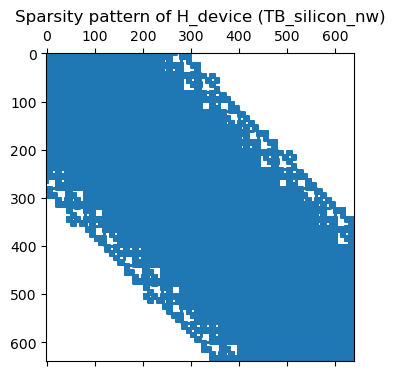

In [26]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Load silicon nanowire TB dataset
_data_dir = Path("../DFT_data/TB_silicon_nw").resolve()

# Core NEGF inputs
energy = np.load(_data_dir / "Energy_grid.npy")
energy_abs_ref = np.load(_data_dir / "Energy_grid_absolute.npy")
sigma_L_ref = np.load(_data_dir / "Sigma_L_stack.npy")
sigma_R_ref = np.load(_data_dir / "Sigma_R_stack.npy")
H_left = np.load(_data_dir / "H_left.npy")
S_left = np.load(_data_dir / "S_left.npy")
H_right = np.load(_data_dir / "H_right.npy")
S_right = np.load(_data_dir / "S_right.npy")
H_device = np.load(_data_dir / "H_device.npy")
S_device = np.load(_data_dir / "S_device.npy")

# Structure metadata requested by you
central_coords_angstrom = np.load(_data_dir / "central_coords_angstrom.npy")
central_elements = np.load(_data_dir / "central_elements.npy")
atom_offsets = np.load(_data_dir / "atom_offsets.npy")

# Optional DOS reference exported by ATK
dos_energy_rel_ref = np.load(_data_dir / "DOS_energies_relative.npy")
dos_total_ref = np.load(_data_dir / "DOS_total.npy")

# Quick sanity checks
print(f"Loaded dataset: {_data_dir.name}")
print(f"H_device shape: {H_device.shape}, S_device shape: {S_device.shape}")
print(f"Central region atoms: {len(central_elements)}")

# Visual check of sparsity
plt.figure(figsize=(5, 4))
plt.spy(H_device, markersize=1)
plt.title("Sparsity pattern of H_device (TB_silicon_nw)")
plt.show()

## determine equilibrium fermi energy

In [27]:
# --- Build electron count + geometry metadata from dataset arrays ---

# Valence model (symbols + atomic numbers)
_valence_by_symbol = {
    "H": 1.0,
    "C": 4.0,
    "Si": 4.0,
}
_valence_by_Z = {
    1: 1.0,
    6: 4.0,
    14: 4.0,
}

elements = np.asarray(central_elements)
if elements.dtype.kind in {"U", "S", "O"}:
    elements_norm = np.array([str(x) for x in elements])
    unique_el, counts_el = np.unique(elements_norm, return_counts=True)
    missing = [el for el in unique_el if el not in _valence_by_symbol]
    if missing:
        raise ValueError(f"Missing valence mapping for element symbols: {missing}")
    N_val = int(round(sum(_valence_by_symbol[el] * int(c) for el, c in zip(unique_el, counts_el))))
    element_summary = dict(zip(unique_el.tolist(), counts_el.tolist()))
else:
    elements_Z = elements.astype(int)
    unique_Z, counts_Z = np.unique(elements_Z, return_counts=True)
    missing = [int(Z) for Z in unique_Z if int(Z) not in _valence_by_Z]
    if missing:
        raise ValueError(f"Missing valence mapping for atomic numbers: {missing}")
    N_val = int(round(sum(_valence_by_Z[int(Z)] * int(c) for Z, c in zip(unique_Z, counts_Z))))
    element_summary = dict(zip(unique_Z.tolist(), counts_Z.tolist()))

# Geometry info from central_coords_angstrom.npy
coord_min = central_coords_angstrom.min(axis=0)
coord_max = central_coords_angstrom.max(axis=0)
span = coord_max - coord_min

N_val = N_val

print("--- TB_silicon_nw metadata ---")
print(f"Elements in central region: {element_summary}")
print(f"Valence electrons (N_val): {N_val}")
print(f"H_device orbitals: {H_device.shape[0]}")
print(f"Central coordinates span [Å]: x={span[0]:.3f}, y={span[1]:.3f}, z={span[2]:.3f}")
print(f"atom_offsets length: {len(atom_offsets)}")

--- TB_silicon_nw metadata ---
Elements in central region: {'H': 64, 'Si': 64}
Valence electrons (N_val): 320
H_device orbitals: 640
Central coordinates span [Å]: x=8.177, y=8.177, z=21.371
atom_offsets length: 65


In [12]:
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor
from negf.gf.recursive_greens_functions import _recursive_inverse

# Build lead principal-layer blocks once
nL = sigma_L_ref.shape[1]
_eta = 1e-6
_damp = 1e-6
_tol = 1e-10

H00_L = H_device[:nL, :nL]
S00_L = S_device[:nL, :nL]
H01_L = H_device[:nL, nL:2*nL]
H10_L = H_device[nL:2*nL, :nL]
S01_L = S_device[:nL, nL:2*nL]
S10_L = S_device[nL:2*nL, :nL]

H00_R = H_device[-nL:, -nL:]
S00_R = S_device[-nL:, -nL:]
H01_R = H_device[-nL:, -2*nL:-nL]
H10_R = H_device[-2*nL:-nL, -nL:]
S01_R = S_device[-nL:, -2*nL:-nL]
S10_R = S_device[-2*nL:-nL, -nL:]

# Wide integration window to capture deep valence states
E_grid = np.linspace(-17.0, 2.0, 1201)

print(f"Computing DOS on wide grid ({len(E_grid)} points) ...")
print(f"Energy window: [{E_grid[0]:.6f}, {E_grid[-1]:.6f}] eV")
print(f"Lead block size: {nL}, Device size: {H_device.shape[0]}")


def _dos_one(i):
    E = float(E_grid[i])

    sigL = sancho_rubio_iterative_greens_function(
        E, h_l=H01_L, h_0=H00_L, h_r=H10_L,
        s_l=S01_L, s_0=S00_L, s_r=S10_L,
        damp=_damp, nconv=_tol,
    )
    sigR = sancho_rubio_iterative_greens_function(
        E, h_l=H01_R, h_0=H00_R, h_r=H10_R,
        s_l=S01_R, s_0=S00_R, s_r=S10_R,
        damp=_damp, nconv=_tol,
    )

    res = _recursive_inverse(
        E, H_device, sigL, sigR,
        compute_lesser=False,
        overlap_matrix=S_device,
        eta=_eta,
        return_trace=True,
        return_diag=False,
        return_gamma=False,
    )

    return float(-np.imag(res[-1]) / np.pi)

_nproc = min(16, mp.cpu_count())
_ctx = mp.get_context("fork")
with ProcessPoolExecutor(max_workers=_nproc, mp_context=_ctx) as ex:
    dos_list = list(ex.map(_dos_one, range(len(E_grid)), chunksize=max(1, len(E_grid)//(_nproc*4))))

dos_negf = np.array(dos_list, dtype=float)
print("Done.")

Computing DOS on wide grid (1201 points) ...
Energy window: [-17.000000, 2.000000] eV
Lead block size: 160, Device size: 640


Done.


Ev = -5.837500 eV
Ec = -2.797500 eV
Ef = (Ec + Ev)/2 = -4.317500 eV


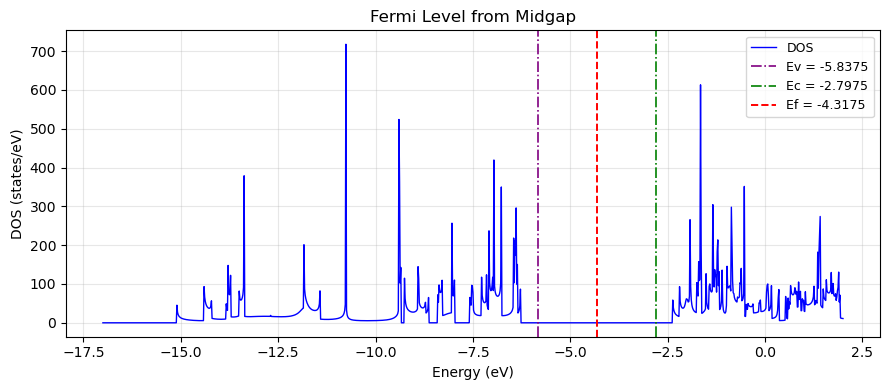

In [13]:
# Ef = (Ec + Ev)/2

# Light smoothing so edge detection is stable
win = 11
kernel = np.ones(win, dtype=float) / win
dos_smooth = np.convolve(dos_negf, kernel, mode="same")

# Low-DOS threshold for gap detection
thresh = min(np.percentile(dos_smooth, 25), 0.05 * float(np.max(dos_smooth)))
low = dos_smooth <= thresh

# Find contiguous low-DOS segments
segments = []
in_seg = False
start = 0
for i, flag in enumerate(low):
    if flag and not in_seg:
        start = i
        in_seg = True
    elif not flag and in_seg:
        segments.append((start, i - 1))
        in_seg = False
if in_seg:
    segments.append((start, len(low) - 1))

# Use widest interior gap
n = len(E_grid)
interior = [(a, b) for (a, b) in segments if a > int(0.03 * n) and b < int(0.97 * n)]
if not interior:
    raise RuntimeError("No interior bandgap found.")

a, b = max(interior, key=lambda t: t[1] - t[0])
Ev = float(E_grid[a - 1])
Ec = float(E_grid[b + 1])
Ef_negf = 0.5 * (Ev + Ec)

print(f"Ev = {Ev:.6f} eV")
print(f"Ec = {Ec:.6f} eV")
print(f"Ef = (Ec + Ev)/2 = {Ef_negf:.6f} eV")

# Simple plot
plt.figure(figsize=(9, 4))
plt.plot(E_grid, 2 * dos_negf, "b-", lw=1, label="DOS")
plt.axvline(Ev, color="purple", ls="-.", lw=1.2, label=f"Ev = {Ev:.4f}")
plt.axvline(Ec, color="green", ls="-.", lw=1.2, label=f"Ec = {Ec:.4f}")
plt.axvline(Ef_negf, color="r", ls="--", lw=1.4, label=f"Ef = {Ef_negf:.4f}")
plt.xlabel("Energy (eV)")
plt.ylabel("DOS (states/eV)")
plt.title("Fermi Level from Midgap")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

# define device

In [ ]:
Ef0 = -4.317500
Ev0 = -5.837500
Ec0 = -2.797500

# scaling
V_0 = 0.026          # voltage scale (V)
L_0 = 1.0e-10        # length scale (m), i.e. 1 Å
N_0 = 1e24           # density scale (m^-3)

# doping
Nd_physical_val = 1.0e23  # 1e17 cm^-3 (Source/Drain)
ni_physical_val = 1.0e16
#Na_physical_val = 2.0e23  # 2e17 cm^-3 (Bulk)
Nd_val = Nd_physical_val / N_0
#Na_val = Na_physical_val / N_0
phi_bi = V_0 * np.log(Nd_physical_val / ni_physical_val)

psi_left_norm = phi_bi / V_0
# constants
q = 1.609e-19
eps_0 = 8.854e-12
poisson_coeff = (q * N_0 * (L_0**2)) / (eps_0 * V_0)

# junction size from channel geometry (central region), in Angstrom
coord_min = central_coords_angstrom.min(axis=0)
coord_max = central_coords_angstrom.max(axis=0)
span = coord_max - coord_min

Lx = float(span[0])
Ly = float(span[1])
Lz = float(span[2])

# normalized dimensions: since L_0 = 1 Å, these are numerically equal to Lx/Ly/Lz in Å
x_dim = Lx
y_dim = Ly
z_dim = Lz

Nx = 100
Ny = 30
Nz = 30

# material property
eps_si_rel = 11.7

V_applied_left = 0
V_applied_right = -3.0
psi_left_norm = V_applied_left / V_0
psi_right_norm = V_applied_right / V_0

print(f"Lx={Lx:.3f} Å, Ly={Ly:.3f} Å, Lz={Lz:.3f} Å")
print(f"normalized box: x_dim={x_dim:.3f}, y_dim={y_dim:.3f}, z_dim={z_dim:.3f}")
print(f"poisson_coeff={poisson_coeff:.6e}")

print(f"Calculated Built-in Potential (Source): {phi_bi:.4f} V")
print(f"Normalized Source BC (psi_left_norm): {psi_left_norm:.4f}")

Lx=8.177 Å, Ly=8.177 Å, Lz=21.371 Å
normalized box: x_dim=8.177, y_dim=8.177, z_dim=21.371
poisson_coeff=6.989453e-03
Calculated Built-in Potential (Source): 0.4191 V
Normalized Source BC (psi_left_norm): 115.3846


# define mesh

In [29]:
from mpi4py import MPI
from dolfinx import mesh
from dolfinx import fem
import ufl
from dolfinx import default_scalar_type
from dolfinx.fem.petsc import LinearProblem
import pyvista
import pyvista as pv
from dolfinx import plot

pyvista.set_jupyter_backend("static")
pyvista.start_xvfb()

# 3D domain (box): [0,0,0] to [x_dim, y_dim, z_dim]
domain = mesh.create_box(
    MPI.COMM_WORLD,
    [[0.0, 0.0, 0.0], [x_dim, y_dim, z_dim]],
    [Nx, Ny, Nz],
    cell_type=mesh.CellType.tetrahedron,
)


/home/nandan_diwan/.conda/envs/negf_env/lib/python3.11/site-packages/pyvista/plotting/utilities/xvfb.py:48: PyVistaDeprecationWarning: This function is deprecated and will be removed in future version of PyVista. Use vtk-osmesa instead.
  warnings.warn(


In [30]:
V = fem.functionspace(domain, ("Lagrange", 1)) # this is the potential transformation space
Q = fem.functionspace(domain, ("DG", 0)) # this is piece wise 

# translation from FEM grid to atomistic grid

In [31]:
from scipy.spatial import cKDTree
from dolfinx import geometry as dfx_geom


class AtomFEMTranslator:
    """Bi-directional translator between atomistic (NEGF) and FEM (dolfinx) grids.

    Atom → FEM:  Gaussian smearing of per-atom scalar values onto DG0 cell grid.
    FEM  → Atom: Point evaluation of a dolfinx Function at atom positions (pooling).

    Parameters
    ----------
    atom_coords_mesh : (N_atoms, 3) ndarray
        Atom positions in the mesh coordinate frame (origin at [0,0,0]).
    domain : dolfinx.mesh.Mesh
    n_orbitals : int
        Total number of orbitals (H_device.shape[0]).
    orbs_per_atom : int or (N_atoms,) array
        Number of basis orbitals per atom.  Scalar → uniform.
    sigma : float or None
        Gaussian smearing width (Å).  If None, median nearest-neighbour distance.
    """

    def __init__(self, atom_coords_mesh, domain, n_orbitals,
                 orbs_per_atom=None, sigma=None):

        self.coords = np.asarray(atom_coords_mesh, dtype=np.float64)
        self.n_atoms = len(self.coords)
        self.n_orbitals = n_orbitals

        # ---- orbital ↔ atom mapping ----
        if orbs_per_atom is None:
            orbs_per_atom = n_orbitals // self.n_atoms
        if np.isscalar(orbs_per_atom):
            orbs_per_atom = np.full(self.n_atoms, int(orbs_per_atom), dtype=int)
        self._orbs_per_atom = np.asarray(orbs_per_atom, dtype=int)
        assert self._orbs_per_atom.sum() == n_orbitals, \
            f"sum(orbs_per_atom)={self._orbs_per_atom.sum()} != n_orbitals={n_orbitals}"

        # cumulative offsets  (length n_atoms + 1)
        self.offsets = np.concatenate(([0], np.cumsum(self._orbs_per_atom)))

        # flat array: orbital index → atom index  (for np.bincount)
        self.orbital_to_atom = np.zeros(n_orbitals, dtype=int)
        for j in range(self.n_atoms):
            self.orbital_to_atom[self.offsets[j]:self.offsets[j + 1]] = j

        # ---- Gaussian sigma ----
        if sigma is None:
            tree = cKDTree(self.coords)
            dd, _ = tree.query(self.coords, k=2)
            sigma = float(np.median(dd[:, 1]))
        self.sigma = sigma

        # ---- cell midpoints (atom → FEM smearing) ----
        _tdim = domain.topology.dim
        _n_cells = domain.topology.index_map(_tdim).size_local
        _cells = np.arange(_n_cells, dtype=np.int32)
        self.cell_mids = mesh.compute_midpoints(domain, _tdim, _cells)
        self.n_cells = _n_cells

        # ---- bounding-box tree (FEM → atom evaluation) ----
        bb = dfx_geom.bb_tree(domain, _tdim)
        candidates = dfx_geom.compute_collisions_points(bb, self.coords)
        colliding = dfx_geom.compute_colliding_cells(
            domain, candidates, self.coords)

        self._atom_cells = np.zeros(self.n_atoms, dtype=np.int32)
        _fallback = 0
        for i in range(self.n_atoms):
            links = colliding.links(i)
            if len(links) > 0:
                self._atom_cells[i] = links[0]
            else:
                dists = np.linalg.norm(
                    self.cell_mids - self.coords[i], axis=1)
                self._atom_cells[i] = np.argmin(dists)
                _fallback += 1

        print(f"AtomFEMTranslator: {self.n_atoms} atoms, "
              f"{self.n_cells} cells, {self.n_orbitals} orbitals "
              f"({self._orbs_per_atom[0]}/atom), σ = {self.sigma:.3f} Å"
              + (f"  ({_fallback} fallback)" if _fallback else ""))

    # ------------------------------------------------------------------ #
    #  orbital ↔ atom aggregation                                        #
    # ------------------------------------------------------------------ #
    def orbitals_to_atoms(self, orbital_vals):
        """Sum orbital-resolved values to per-atom values."""
        return np.bincount(self.orbital_to_atom,
                           weights=np.real(orbital_vals),
                           minlength=self.n_atoms)

    def atoms_to_orbitals(self, atom_vals):
        """Expand per-atom values to the orbital basis (constant within each atom)."""
        return np.asarray(atom_vals, dtype=np.float64)[self.orbital_to_atom]

    # ------------------------------------------------------------------ #
    #  atom → FEM  (Gaussian smearing)                                   #
    # ------------------------------------------------------------------ #
    def atom_to_fem(self, atom_values):
        """Gaussian-smear per-atom values onto DG0 cell midpoints.

        f(r_cell) = Σ_i  w_i v_i  /  Σ_i w_i
        with  w_i = exp( -|r_cell - r_atom_i|² / 2σ² ).

        Parameters
        ----------
        atom_values : (N_atoms,)

        Returns
        -------
        cell_values : (n_cells,)
        """
        v = np.asarray(atom_values, dtype=np.float64)
        result = np.zeros(self.n_cells, dtype=np.float64)
        norm   = np.zeros(self.n_cells, dtype=np.float64)
        inv_2s2 = 1.0 / (2.0 * self.sigma ** 2)

        for i in range(self.n_atoms):
            d = self.cell_mids - self.coords[i]
            w = np.exp(-np.sum(d * d, axis=1) * inv_2s2)
            result += w * v[i]
            norm   += w

        norm[norm == 0] = 1.0
        return result / norm

    # ------------------------------------------------------------------ #
    #  FEM → atom  (point evaluation / pooling)                          #
    # ------------------------------------------------------------------ #
    def fem_to_atom(self, fem_func):
        """Evaluate a dolfinx Function at each atom position.

        Parameters
        ----------
        fem_func : dolfinx.fem.Function

        Returns
        -------
        atom_values : (N_atoms,)
        """
        vals = fem_func.eval(self.coords, self._atom_cells)
        return np.asarray(vals, dtype=np.float64).flatten()

    # ------------------------------------------------------------------ #
    #  compound helpers                                                  #
    # ------------------------------------------------------------------ #
    def orbital_to_fem(self, orbital_vals):
        """orbital values → atom sum → Gaussian smear to FEM cells."""
        return self.atom_to_fem(self.orbitals_to_atoms(orbital_vals))

    def fem_to_orbital(self, fem_func):
        """FEM function → atom eval → expand to orbital basis."""
        return self.atoms_to_orbitals(self.fem_to_atom(fem_func))


# ------------------------------------------------------------------ #
#  Instantiate                                                       #
# ------------------------------------------------------------------ #
atom_coords_mesh = central_coords_angstrom - central_coords_angstrom.min(axis=0)

translator = AtomFEMTranslator(
    atom_coords_mesh=atom_coords_mesh,
    domain=domain,
    n_orbitals=H_device.shape[0],      # 640
)

# Preparation

AtomFEMTranslator: 128 atoms, 540000 cells, 640 orbitals (5/atom), σ = 1.480 Å


### testing

In [32]:
# --- Round-trip tests ---

# 1) orbital ↔ atom: constant per-atom value round-trips correctly
dummy_atom = np.arange(translator.n_atoms, dtype=float)
orb = translator.atoms_to_orbitals(dummy_atom)
back = translator.orbitals_to_atoms(orb)
n_orbs_per_atom = translator._orbs_per_atom
assert np.allclose(back, dummy_atom * n_orbs_per_atom), "orbital round-trip failed"
print("✓ orbital ↔ atom round-trip")

# 2) atom → FEM: constant field stays constant after smearing
const_val = 7.0
cell_vals = translator.atom_to_fem(np.full(translator.n_atoms, const_val))
assert np.allclose(cell_vals, const_val, atol=1e-10), \
    f"constant smearing failed: [{cell_vals.min():.6f}, {cell_vals.max():.6f}]"
print(f"✓ atom→FEM constant field  (range [{cell_vals.min():.6f}, {cell_vals.max():.6f}])")

# 3) FEM → atom: linear field f(x,y,z) = z evaluated at atoms
phi_test = fem.Function(V)
phi_test.interpolate(lambda x: x[2])
z_at_atoms = translator.fem_to_atom(phi_test)
err = np.max(np.abs(z_at_atoms - atom_coords_mesh[:, 2]))
print(f"✓ FEM→atom linear field  (max err = {err:.2e})")

# 4) summary
print(f"\n  atoms     = {translator.n_atoms}")
print(f"  orbitals  = {translator.n_orbitals}  ({n_orbs_per_atom[0]}/atom)")
print(f"  FEM cells = {translator.n_cells}")
print(f"  σ         = {translator.sigma:.3f} Å")


✓ orbital ↔ atom round-trip
✓ atom→FEM constant field  (range [7.000000, 7.000000])
✓ FEM→atom linear field  (max err = 3.55e-15)

  atoms     = 128
  orbitals  = 640  (5/atom)
  FEM cells = 540000
  σ         = 1.480 Å


# hamiltonian 

In [33]:
class Hamiltonian:
    """Hamiltonian helper for self-consistent NEGF-Poisson updates.

    Convention used here (typical for NEGF-Poisson in TB):
    - Keep the material/band structure inside H0 (already contains Ec/Ev alignment).
    - Update electrostatics each iteration via onsite shift U(r).
    - For electrons: U_e[eV] = -phi[V].
      So the diagonal update is H_ii <- H0_ii + U_i.

    Input potential is atom-indexed and expanded to orbitals with the same
    mapping convention as `translator.atoms_to_orbitals(...)`.
    """

    def __init__(self, H_device, S_device, nL, translator, V0=0.026):
        self.H0 = np.array(H_device, copy=True)
        self.S = S_device
        self.n = self.H0.shape[0]
        self.nL = int(nL)
        self.translator = translator
        self.V0 = float(V0)
        
        self._diag_idx = np.arange(self.n)
        self._H_work = np.array(self.H0, copy=True)
        self._H0_diag = np.real(np.diag(self.H0)).copy()

        self.H00_L = self.H0[:nL, :nL]
        self.S00_L = self.S[:nL, :nL]
        self.H01_L = self.H0[:nL, nL:2*nL]
        self.H10_L = self.H0[nL:2*nL, :nL]
        self.S01_L = self.S[:nL, nL:2*nL]
        self.S10_L = self.S[nL:2*nL, :nL]

        self.H00_R = self.H0[-nL:, -nL:]
        self.S00_R = self.S[-nL:, -nL:]
        self.H01_R = self.H0[-nL:, -2*nL:-nL]
        self.H10_R = self.H0[-2*nL:-nL, -nL:]
        self.S01_R = self.S[-nL:, -2*nL:-nL]
        self.S10_R = self.S[-2*nL:-nL, -nL:]

    def _atom_potential_to_orbital_shift_eV(self, phi_atom, potential_kind="voltage"):
        """Convert atom-indexed potential to orbital-indexed onsite shift in eV.

        Parameters
        ----------
        phi_atom : (N_atoms,)
            Atom-indexed potential.
        potential_kind : str
            "voltage"            -> phi in volts, shift = -phi
            "normalized_voltage" -> phi normalized by V0, shift = -(phi*V0)
            "energy_eV"          -> directly use shift in eV
        """
        phi_atom = np.asarray(phi_atom, dtype=np.float64)

        if potential_kind == "voltage":
            shift_atom_eV = -phi_atom
        elif potential_kind == "normalized_voltage":
            shift_atom_eV = -(phi_atom * self.V0)
        elif potential_kind == "energy_eV":
            shift_atom_eV = phi_atom
        else:
            raise ValueError(
                "potential_kind must be one of: 'voltage', 'normalized_voltage', 'energy_eV'"
            )

        return self.translator.atoms_to_orbitals(shift_atom_eV)

    def update_device_hamiltonian(self, phi_atom, potential_kind="voltage", return_copy=False):
        """Apply atom-indexed electrostatic potential as onsite update.

        Efficient path: reuses a working matrix and only overwrites the diagonal.
        """
        shift_orb_eV = self._atom_potential_to_orbital_shift_eV(
            phi_atom=phi_atom, potential_kind=potential_kind
        )

        self._H_work[:, :] = self.H0
        self._H_work[self._diag_idx, self._diag_idx] = self._H0_diag + shift_orb_eV

        if return_copy:
            return np.array(self._H_work, copy=True)
        return self._H_work

    def update_from_fem_function(self, fem_phi, potential_kind="normalized_voltage", return_copy=False):
        """Convenience wrapper: FEM function -> atom values -> updated H.

        Use `potential_kind='normalized_voltage'` for your current Poisson unknown psi.
        """
        phi_atom = self.translator.fem_to_atom(fem_phi)
        return self.update_device_hamiltonian(
            phi_atom=phi_atom, potential_kind=potential_kind, return_copy=return_copy
        )


nL_for_hamiltonian = int(nL) if "nL" in globals() else int(sigma_L_ref.shape[1])
hamiltonian = Hamiltonian(
    H_device=H_device,
    S_device=S_device,
    nL=nL_for_hamiltonian,
    translator=translator,
    V0=V_0,

)
print(f"Hamiltonian helper ready: n={hamiltonian.n}, nL={hamiltonian.nL}")

Hamiltonian helper ready: n=640, nL=160


In [34]:
phi_atom_test = np.zeros(translator.n_atoms, dtype=float)
phi_atom_test -= Ef0  # shift the fermi level every iteration 

H_eff = hamiltonian.update_device_hamiltonian(
    phi_atom=phi_atom_test,
    potential_kind="voltage",
    return_copy=False,

)

# doping and bc

In [35]:
Eg = Ec0 - Ev0 # Ec0 and Ev0 are not shifted yet 
fdim = domain.topology.dim - 1

# left/right on z-min/z-max faces (transport along z)
left_facets = mesh.locate_entities_boundary(
    domain, fdim, lambda x: np.isclose(x[2], 0.0)
)
right_facets = mesh.locate_entities_boundary(
    domain, fdim, lambda x: np.isclose(x[2], z_dim)
)

left_dofs = fem.locate_dofs_topological(V, fdim, left_facets)
right_dofs = fem.locate_dofs_topological(V, fdim, right_facets)

# 1. DIRICHLET BC AT SOURCE (Left)
bc_left = fem.dirichletbc(default_scalar_type(psi_left_norm), left_dofs, V)

# 2. NEUMANN BC AT DRAIN (Right)
# By omitting right_dofs from the bcs list, FEniCS automatically enforces d(phi)/dz = 0
bcs = [bc_left] 

# n-i-n Doping arrays (DG0)
Nd_norm = fem.Function(Q)
Na_norm = fem.Function(Q)

# Cell centers (local cells)
tdim = domain.topology.dim
num_local_cells = domain.topology.index_map(tdim).size_local
all_cells = np.arange(num_local_cells, dtype=np.int32)
mids = mesh.compute_midpoints(domain, tdim, all_cells)
zm = mids[:, 2]

# Define n-i-n regions (Let's make the channel the middle third for this example)
z_source_end = z_dim / 3.0
z_drain_start = 2.0 * z_dim / 3.0

is_source = zm < z_source_end
is_drain = zm > z_drain_start
is_channel = ~(is_source | is_drain) # Intrinsic region

# Fill DG0 arrays (normalized concentrations)
Nd_array = np.zeros_like(Nd_norm.x.array, dtype=default_scalar_type)
Na_array = np.zeros_like(Na_norm.x.array, dtype=default_scalar_type) # Stays 0 for n-i-n

# Apply Donor doping to Source and Drain regions
Nd_array[all_cells[is_source]] = default_scalar_type(Nd_val)
Nd_array[all_cells[is_drain]] = default_scalar_type(Nd_val)
# Intrinsic channel naturally remains 0.0

Nd_norm.x.array[:] = Nd_array
Na_norm.x.array[:] = Na_array

# Net doping for visualization/debug
net_doping = Nd_norm.x.array.real - Na_norm.x.array.real

print("--- BC and n-i-n doping setup (along z) ---")
print(f"left dofs (Dirichlet): {len(left_dofs)}, right dofs (Neumann): {len(right_dofs)}")
print(f"Source region: z < {z_source_end:.3f}")
print(f"Drain region: z > {z_drain_start:.3f}")
print(f"Source cells: {np.count_nonzero(is_source)}")
print(f"Channel cells: {np.count_nonzero(is_channel)}")
print(f"Drain cells: {np.count_nonzero(is_drain)}")
print(f"Net doping range: [{net_doping.min():.3e}, {net_doping.max():.3e}]")

--- BC and n-i-n doping setup (along z) ---
left dofs (Dirichlet): 3131, right dofs (Neumann): 3131
Source region: z < 7.124
Drain region: z > 14.247
Source cells: 180000
Channel cells: 180000
Drain cells: 180000
Net doping range: [0.000e+00, 1.000e-01]


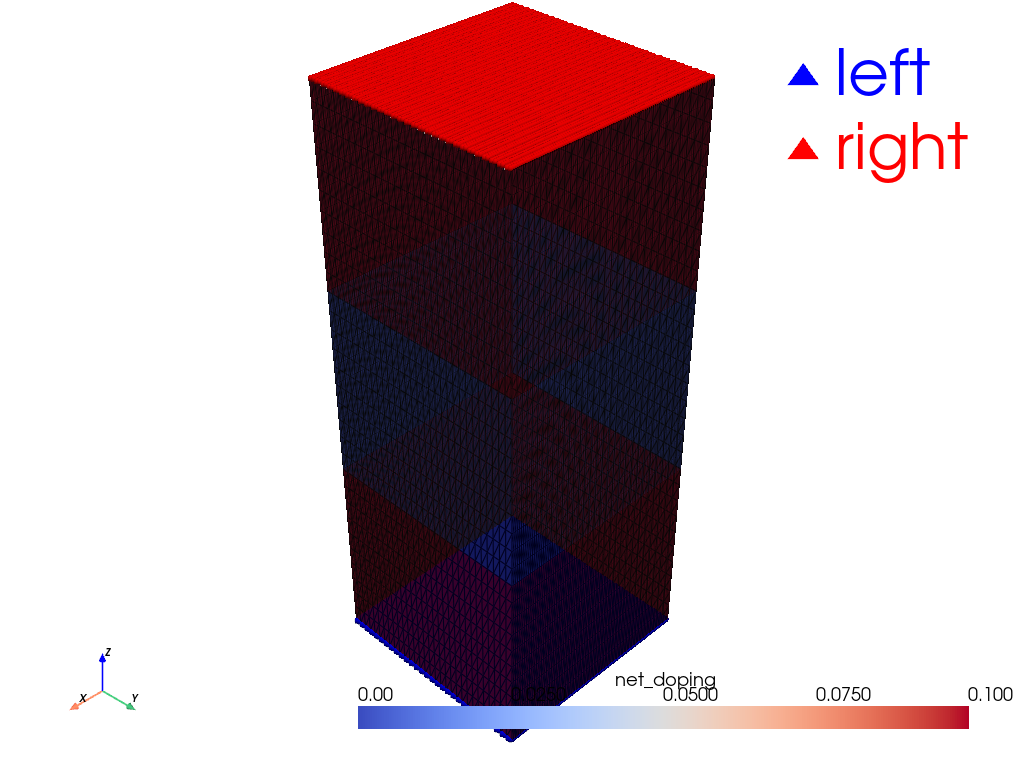

In [36]:
# Minimal visualization: mesh + net doping + BC markers
import pyvista as pv
from dolfinx import plot

# Build VTK grid from mesh topology
topo, cell_types, geom = plot.vtk_mesh(domain, domain.topology.dim)
grid = pv.UnstructuredGrid(topo, cell_types, geom)

# Attach cell-wise net doping (trim if needed)
grid.cell_data["net_doping"] = np.asarray(net_doping[: grid.n_cells], dtype=float)

# Boundary facet midpoints for markers (z-faces)
left_mid = mesh.compute_midpoints(domain, fdim, left_facets)
right_mid = mesh.compute_midpoints(domain, fdim, right_facets)

p = pv.Plotter()
p.add_mesh(grid, scalars="net_doping", show_edges=True, cmap="coolwarm", opacity=0.85)
p.add_points(left_mid, color="blue", point_size=7, render_points_as_spheres=True, label="left")
p.add_points(right_mid, color="red", point_size=7, render_points_as_spheres=True, label="right")
p.add_legend()
p.show_axes()
p.show()

# Solver

## initial poisson solve

In [ ]:
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
from dolfinx import geometry as dfx_geom_solver

# ─── Semiclassical charge model ────────────────────────────────────────
# Effective density-of-states prefactors (include 2/√π for FD_half convention)
Nc = 2.8e25 * (2.0 / np.sqrt(np.pi))   # m^-3
Nv = 1.04e25 * (2.0 / np.sqrt(np.pi))  # m^-3
kbT = V_0  # 0.026 eV at 300 K

# Band edges in the Ef = 0 reference frame (eV)
Ec_ref = Ec0 - Ef0   # conduction band edge above Ef (> 0)
Ev_ref = Ev0 - Ef0   # valence band edge below Ef   (< 0)

def _FD_half(x):
    """Fermi-Dirac integral of order 1/2.
    Ref: http://dx.doi.org/10.1063/1.4825209
    """
    v = x**4 + 50 + 33.6 * x * (1 - 0.68 * np.exp(-0.17 * (x + 1)**2))
    return 1.0 / (np.exp(-x) + (3.0 * np.pi**0.5 / 4.0) * v**(-3.0 / 8.0))

def get_semiclassical_charge(psi_norm, Nd_phys, Na_phys):
    """Compute normalized charge density from normalized potential ψ = φ/V₀.

    Parameters
    ----------
    psi_norm : float or array  –  φ / V₀ (dimensionless)
    Nd_phys, Na_phys : float or array  –  physical doping (m⁻³)

    Returns
    -------
    rho_norm : (p - n + Nd - Na) / N₀
    n_phys   : electron concentration (m⁻³)
    p_phys   : hole concentration (m⁻³)
    """
    psi_eV = psi_norm * V_0

    # Shifted band edges (Ef = 0)
    Ec_eff = Ec_ref - psi_eV
    Ev_eff = Ev_ref - psi_eV

    # Reduced Fermi energies
    eta_e = -Ec_eff / kbT        # (Ef − Ec_eff) / kT
    eta_h =  Ev_eff / kbT        # (Ev_eff − Ef) / kT

    n = Nc * _FD_half(eta_e)
    p = Nv * _FD_half(eta_h)

    rho_norm = (p - n + Nd_phys - Na_phys) / N_0
    return rho_norm, n, p

# ─── Built-in potential (charge neutrality in n-doped region) ──────────
def _charge_neutrality(psi_guess):
    rho, _, _ = get_semiclassical_charge(psi_guess, Nd_physical_val, 0.0)
    return rho

# Initial guess near Ec_ref / V₀ (Boltzmann regime)
psi_bi_norm = float(fsolve(_charge_neutrality, Ec_ref / V_0)[0])
phi_bi_eV = psi_bi_norm * V_0

print(f"Band edges (Ef=0 frame): Ec_ref = {Ec_ref:.4f} eV, Ev_ref = {Ev_ref:.4f} eV")
print(f"Nanowire bandgap: Eg = {Ec_ref - Ev_ref:.4f} eV")
print(f"Built-in potential: φ_bi = {phi_bi_eV:.4f} V  (ψ_norm = {psi_bi_norm:.4f})")

# Verify
rho_chk, n_chk, _ = get_semiclassical_charge(psi_bi_norm, Nd_physical_val, 0.0)
print(f"Charge neutrality check: ρ/N₀ = {rho_chk:.2e},  n = {n_chk:.2e} m⁻³,  Nd = {Nd_physical_val:.2e} m⁻³")

In [ ]:
# ─── Boundary Conditions for Poisson ──────────────────────────────────
# Left lead (z = 0):  Dirichlet at built-in potential  (Ef = 0 reference)
# Right lead (z = z_dim):  Neumann (floating)  – enforced by omission

bc_left_poisson = fem.dirichletbc(default_scalar_type(psi_bi_norm), left_dofs, V)
bcs_poisson = [bc_left_poisson]

# ─── Permittivity (uniform silicon) ──────────────────────────────────
eps_rel = fem.Function(Q)
eps_rel.x.array[:] = eps_si_rel

# ─── Bilinear / linear forms ─────────────────────────────────────────
u_psi = ufl.TrialFunction(V)
v_psi = ufl.TestFunction(V)

a_poisson = ufl.inner(eps_rel * ufl.grad(u_psi), ufl.grad(v_psi)) * ufl.dx
L_poisson = fem.Constant(domain, default_scalar_type(0.0)) * v_psi * ufl.dx

# ─── Initial Laplace solve (ρ = 0) ───────────────────────────────────
problem_init = LinearProblem(
    a_poisson, L_poisson, bcs=bcs_poisson,
    petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
)
phi_init = problem_init.solve()
phi_init.name = "psi_laplace"

print(f"Laplace solve done.  ψ range: [{phi_init.x.array.min():.4f}, {phi_init.x.array.max():.4f}]")
print(f"Potential range: [{phi_init.x.array.min()*V_0:.4f}, {phi_init.x.array.max()*V_0:.4f}] V")

## nonlinear Poisson iteration (Newton/Gummel)

In [ ]:
# ─── Nonlinear Poisson (Newton/Gummel linearization) ──────────────────
phi_poisson = fem.Function(V)
phi_poisson.x.array[:] = phi_init.x.array.copy()

rho_func  = fem.Function(Q)
drho_func = fem.Function(Q)

# Physical doping at cell midpoints (m⁻³)
Nd_phys_cells = np.zeros(num_local_cells, dtype=float)
Nd_phys_cells[is_source] = Nd_physical_val
Nd_phys_cells[is_drain]  = Nd_physical_val
Na_phys_cells = np.zeros(num_local_cells, dtype=float)  # zero for n-i-n

max_iter   = 500
tol        = 1e-6
max_update = 1.0   # clamp step (normalized units)

print("Starting nonlinear Poisson iteration ...")
for it in range(max_iter):
    # Evaluate ψ at cell midpoints
    phi_vals = phi_poisson.eval(mids, all_cells)[:, 0]

    # Semiclassical charge and Jacobian dρ/dψ
    rho_vals, n_phys, p_phys = get_semiclassical_charge(
        phi_vals, Nd_phys_cells, Na_phys_cells
    )
    drho_vals = -(n_phys + p_phys) / N_0          # dρ_norm / dψ

    rho_func.x.array[:]  = rho_vals
    drho_func.x.array[:] = drho_vals

    # Gummel-linearized system:
    #   a_gummel · ψ_new = L_gummel
    # where the Jacobian term is absorbed into the LHS
    a_gummel = (
        a_poisson
        - poisson_coeff * drho_func * u_psi * v_psi * ufl.dx
    )
    L_gummel = (
        poisson_coeff * (rho_func - drho_func * phi_poisson) * v_psi * ufl.dx
    )

    problem_nl = LinearProblem(
        a_gummel, L_gummel, bcs=bcs_poisson,
        petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
    )
    phi_new = problem_nl.solve()

    delta = phi_new.x.array - phi_poisson.x.array
    error = float(np.max(np.abs(delta)))

    # Clamped update to prevent exponential blow-up
    phi_poisson.x.array[:] += np.clip(delta, -max_update, max_update)

    if it % 20 == 0 or error < tol:
        print(f"  Iter {it+1:4d}: max |Δψ| = {error:.4e}")

    if error < tol:
        print(f"Converged in {it+1} iterations!")
        break
else:
    print(f"WARNING: did not converge (final error = {error:.4e})")

phi_phys_min = phi_poisson.x.array.min() * V_0
phi_phys_max = phi_poisson.x.array.max() * V_0
print(f"Potential range: [{phi_phys_min:.4f}, {phi_phys_max:.4f}] V")

In [ ]:
# ─── Visualization: 1D potential + band diagram ──────────────────────

# Probe points along z at cross-section center
x_mid, y_mid = x_dim / 2.0, y_dim / 2.0
z_pts = np.linspace(0, z_dim, 200)
probe_pts = np.column_stack([
    np.full_like(z_pts, x_mid),
    np.full_like(z_pts, y_mid),
    z_pts,
])

bb = dfx_geom_solver.bb_tree(domain, domain.topology.dim)
cell_cands = dfx_geom_solver.compute_collisions_points(bb, probe_pts)
colliding  = dfx_geom_solver.compute_colliding_cells(domain, cell_cands, probe_pts)

pts_ok, cells_ok = [], []
for i in range(len(probe_pts)):
    links = colliding.links(i)
    if len(links) > 0:
        pts_ok.append(probe_pts[i])
        cells_ok.append(links[0])
pts_ok = np.array(pts_ok)

psi_line   = phi_poisson.eval(pts_ok, cells_ok).flatten()
phi_line_V = psi_line * V_0
z_line     = pts_ok[:, 2]

# Band edges along z
Ec_line = Ec_ref - psi_line * V_0   # eV, Ef = 0 frame
Ev_line = Ev_ref - psi_line * V_0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: electrostatic potential
axes[0].plot(z_line, phi_line_V, "b-", lw=2)
axes[0].axvline(z_source_end,  color="gray", ls="--", label="source/channel")
axes[0].axvline(z_drain_start, color="gray", ls="--", label="channel/drain")
axes[0].set_xlabel("z (Å)")
axes[0].set_ylabel("Electrostatic potential φ (V)")
axes[0].set_title("Potential along z (center of cross-section)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: band diagram
axes[1].plot(z_line, Ec_line, "r-", lw=2, label="Ec")
axes[1].plot(z_line, Ev_line, "b-", lw=2, label="Ev")
axes[1].axhline(0, color="k", ls="--", lw=1, label="Ef = 0")
axes[1].axvline(z_source_end,  color="gray", ls="--", alpha=0.5)
axes[1].axvline(z_drain_start, color="gray", ls="--", alpha=0.5)
axes[1].set_xlabel("z (Å)")
axes[1].set_ylabel("Energy (eV)")
axes[1].set_title("Band diagram (Ef = 0 frame)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()